<a href="https://colab.research.google.com/github/Nikesh5005/ML_PROJ/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
from google.colab import drive
drive.mount('/content/drive')



!mkdir -p /root/.config /root/.local/share /root/.local/state

!ln -sf /content/drive/MyDrive/opencode-data/config /root/.config/opencode
!ln -sf /content/drive/MyDrive/opencode-data/share /root/.local/share/opencode
!ln -sf /content/drive/MyDrive/opencode-data/state /root/.local/state/opencode

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [79]:
  df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [80]:
df.isnull().any()

,0
Age,False
Attrition,False
BusinessTravel,False
DailyRate,False
Department,False
DistanceFromHome,False
Education,False
EducationField,False
EmployeeCount,False
EmployeeNumber,False


In [81]:

num_col=df.select_dtypes(include='number').columns.to_list()
num_col


['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [82]:
df.duplicated().any()

np.False_

<Axes: xlabel='DistanceFromHome', ylabel='Attrition'>

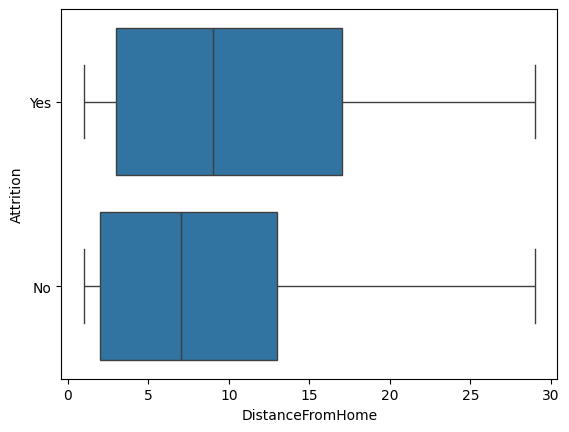

In [83]:
sns.boxplot(data=df,x='DistanceFromHome',y='Attrition')

In [84]:
pd.crosstab(df['JobRole'], df['Attrition'], normalize='index')

Attrition,No,Yes
JobRole,,
Healthcare Representative,0.931298,0.068702
Human Resources,0.769231,0.230769
Laboratory Technician,0.760618,0.239382
Manager,0.950980,0.049020
Manufacturing Director,0.931034,0.068966
Research Director,0.975000,0.025000
Research Scientist,0.839041,0.160959
Sales Executive,0.825153,0.174847
Sales Representative,0.602410,0.397590


so we can clearly see that JobRole is the strong predictor for deciding Attrition employee in job role like Sales Representative,Human Resources,Laboratory Technician are more likely to leave then other jobrole



<Axes: xlabel='MonthlyIncome'>

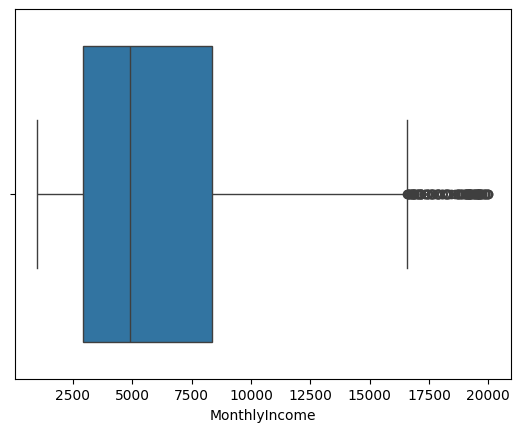

In [85]:
sns.boxplot(data=df, x='MonthlyIncome')

<Axes: xlabel='MonthlyIncome', ylabel='Attrition'>

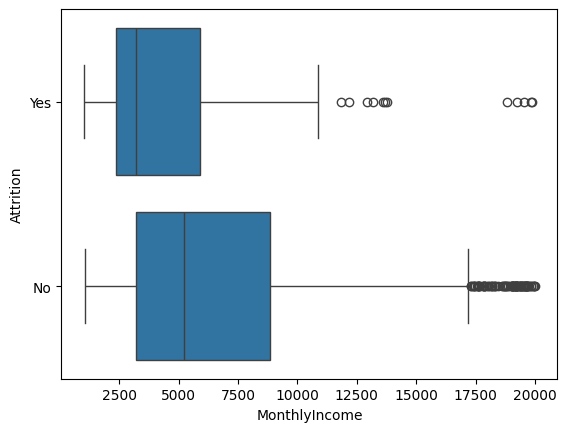

In [86]:
sns.boxplot(data=df, x='MonthlyIncome',y='Attrition')

we can clearly observe that employee who left  tend to have lower median MonthlyIncome then who said no(stayed)
this suggest that lower paid employee are more likely to leave and which also make a sense so monthly income can be a strong feature to decide wheather a employee stayed or not

<Axes: xlabel='MonthlyIncome', ylabel='Density'>

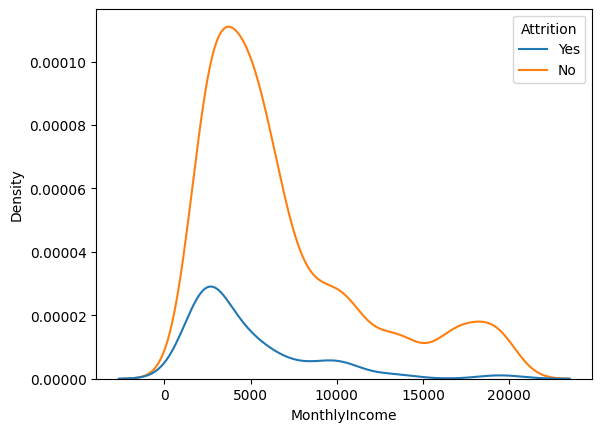

In [87]:
sns.kdeplot(data=df, x='MonthlyIncome',hue='Attrition')

In [88]:
df.groupby('JobLevel')['MonthlyIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
JobLevel,,,,,,,,
1,543.0,2786.915285,748.634767,1009.0,2306.0,2670.0,3207.00,4968.0
2,534.0,5502.277154,1410.029686,2042.0,4544.0,5340.0,6273.50,9998.0
3,218.0,9817.252294,1805.999233,5210.0,8383.0,9980.0,10814.50,13757.0
4,106.0,15503.783019,1816.239003,11103.0,13761.0,16154.0,17036.25,17924.0
5,69.0,19191.826087,512.383127,18041.0,18880.0,19232.0,19586.00,19999.0


<Axes: xlabel='MonthlyIncome', ylabel='Density'>

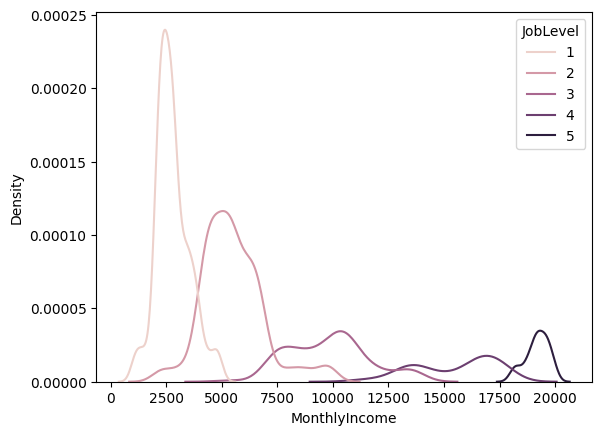

In [89]:
sns.kdeplot(data=df, x='MonthlyIncome',hue='JobLevel')

In [90]:
pd.crosstab(df['JobLevel'], df['Attrition'], normalize='index')

Attrition,No,Yes
JobLevel,,
1,0.736648,0.263352
2,0.902622,0.097378
3,0.853211,0.146789
4,0.952830,0.047170
5,0.927536,0.072464



since  MonthlyIncome is multimodel the peaks corresponds to  MonthlyIncome is found to be JobLevel so we can group MonthlyIncome by joblevel and found that enployee having  low joblevel have less  MonthlyIncome having  MonthlyIncome indicate hing chance of leaving .

In [91]:
role_avg_income = df.groupby('JobLevel')['MonthlyIncome'].transform('mean')
role_avg_income

,MonthlyIncome
0,5502.277154
1,5502.277154
2,2786.915285
3,2786.915285
4,2786.915285
...,...
1465,5502.277154
1466,9817.252294
1467,5502.277154
1468,5502.277154


In [92]:
df['IncomeRatio'] = df['MonthlyIncome'] / role_avg_income

<Axes: xlabel='IncomeRatio', ylabel='Attrition'>

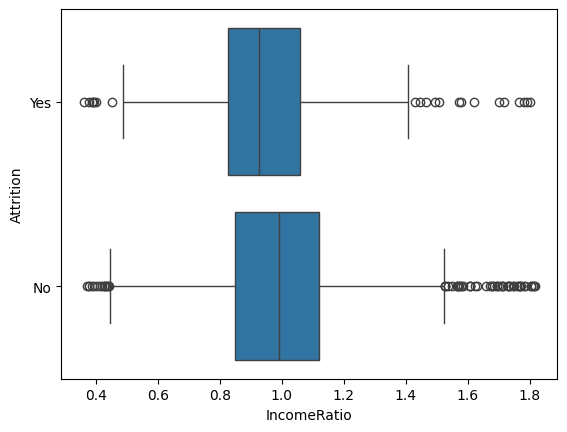

In [93]:
sns.boxplot(data=df,x="IncomeRatio",y='Attrition')

clearly seeing that having low incomeratio tends to leave more

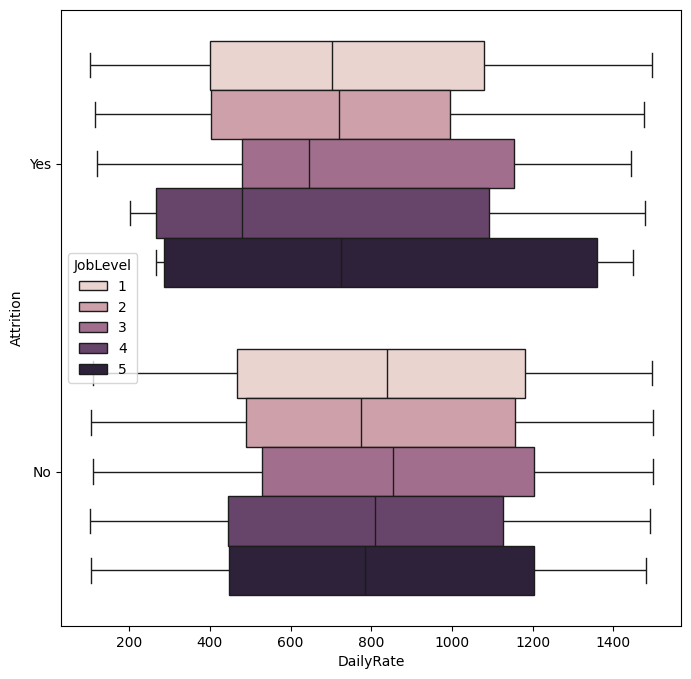

In [94]:

plt.figure(figsize=(8,8))
sns.boxplot(data=df,x='DailyRate',y='Attrition',hue='JobLevel')
plt.show()

here we can clearly see that  Employees who left have lower median DailyRate .This holds within EVERY JobLevel so it can be a important predictor  

In [95]:
df['MonthlyIncome'].corr(df['DailyRate'])

np.float64(0.007707058872006017)

<Axes: xlabel='DailyRate', ylabel='Density'>

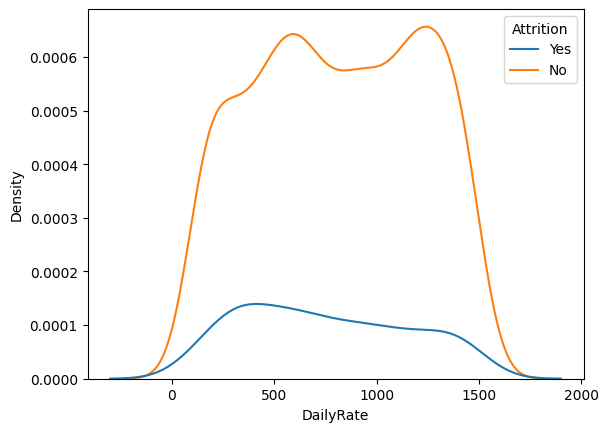

In [96]:
sns.kdeplot(data=df,x='DailyRate',hue='Attrition')

<Axes: xlabel='OverTime', ylabel='count'>

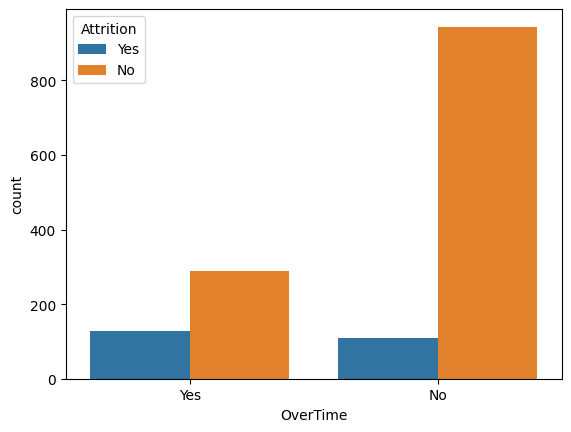

In [97]:
sns.countplot(data=df, x='OverTime', hue='Attrition')

In [98]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')

Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


In [99]:
pd.crosstab(df['NumCompaniesWorked'], df['Attrition'], normalize='index')

Attrition,No,Yes
NumCompaniesWorked,,
0,0.883249,0.116751
1,0.811900,0.188100
2,0.890411,0.109589
3,0.899371,0.100629
4,0.877698,0.122302
5,0.746032,0.253968
6,0.771429,0.228571
7,0.770270,0.229730
8,0.877551,0.122449


soo we can clearly see that employee who have changed there job frequently have more chance to leave. so we can make a new column that tells how frequently someone switch a job. employee having more frequency tends or have more chance  to leave job  

In [102]:
df['job_change_frequency']=np.where(df['TotalWorkingYears']>0,df['NumCompaniesWorked']/df['TotalWorkingYears'],0)

In [103]:
df['job_change_frequency']

,job_change_frequency
0,1.000000
1,0.100000
2,0.857143
3,0.125000
4,1.500000
...,...
1465,0.235294
1466,0.444444
1467,0.166667
1468,0.117647


we can also see that overtime feature can also be a strong predictor , seeing the pattern that employee doing overtime are more likely to leave .

In [105]:
output=df['Attrition']
input=df.drop(labels='Attrition',axis=1)
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'IncomeRatio', 'job_change_frequency'],
      dtype='object')

In [106]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    input, output, test_size=0.30, random_state=42)

In [107]:
input_cat_column=X_train.select_dtypes(include='object').columns.to_list()
input_num_column=X_train.select_dtypes(include='number').columns.to_list()

In [108]:
from sklearn.preprocessing import OneHotEncoder

In [109]:
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)

In [110]:
encoder.fit(X_train[input_cat_column])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [111]:
encoder.categories_

[array(['Non-Travel', 'Travel_Frequently', 'Travel_Rarely'], dtype=object),
 array(['Human Resources', 'Research & Development', 'Sales'], dtype=object),
 array(['Human Resources', 'Life Sciences', 'Marketing', 'Medical',
        'Other', 'Technical Degree'], dtype=object),
 array(['Female', 'Male'], dtype=object),
 array(['Healthcare Representative', 'Human Resources',
        'Laboratory Technician', 'Manager', 'Manufacturing Director',
        'Research Director', 'Research Scientist', 'Sales Executive',
        'Sales Representative'], dtype=object),
 array(['Divorced', 'Married', 'Single'], dtype=object),
 array(['Y'], dtype=object),
 array(['No', 'Yes'], dtype=object)]

In [112]:
encoded_col=list(encoder.get_feature_names_out(input_cat_column))
encoded_col

['BusinessTravel_Non-Travel',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Department_Human Resources',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Human Resources',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Gender_Female',
 'Gender_Male',
 'JobRole_Healthcare Representative',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Scientist',
 'JobRole_Sales Executive',
 'JobRole_Sales Representative',
 'MaritalStatus_Divorced',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'Over18_Y',
 'OverTime_No',
 'OverTime_Yes']

In [113]:
X_train_encoded=pd.DataFrame(encoder.transform(X_train[input_cat_column]),columns=encoded_col,index=X_train.index)
X_test_encoded=pd.DataFrame(encoder.transform(X_test[input_cat_column]),columns=encoded_col,index=X_test.index)

In [114]:
X_test=pd.concat([X_test,X_test_encoded],axis=1)
X_train=pd.concat([X_train,X_train_encoded],axis=1)

In [115]:
X_test=X_test.drop(labels=(input_cat_column),axis=1)
X_train=X_train.drop(labels=(input_cat_column),axis=1)

In [118]:
X_test

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
1041,28,866,5,3,1,1469,4,84,3,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
184,53,1084,13,2,1,250,4,57,4,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1222,24,240,22,1,1,1714,4,58,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
67,45,1339,7,3,1,86,2,59,3,3,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
220,36,1396,5,2,1,304,4,62,3,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1047,33,430,7,3,1,1477,4,54,3,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
331,27,210,1,1,1,449,3,73,3,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
323,28,1157,2,4,1,440,1,84,1,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
654,39,1383,2,3,1,909,4,42,2,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [119]:
import pickle

save_path = "/content/drive/MyDrive/train_test_val_data/"

with open(save_path + 'X_train_DT.pkl', 'wb') as f:
    pickle.dump(X_train, f)

with open(save_path + 'X_test_DT.pkl', 'wb') as f:
    pickle.dump(X_test, f)

with open(save_path + 'y_train_DT.pkl', 'wb') as f:
    pickle.dump(y_train, f)

with open(save_path + 'y_test_DT.pkl', 'wb') as f:
    pickle.dump(y_test, f)